In [1]:
print("Employee Attrition Analysis")
print("Python is working!")

Employee Attrition Analysis
Python is working!


In [11]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1470, 35)


In [12]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [14]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


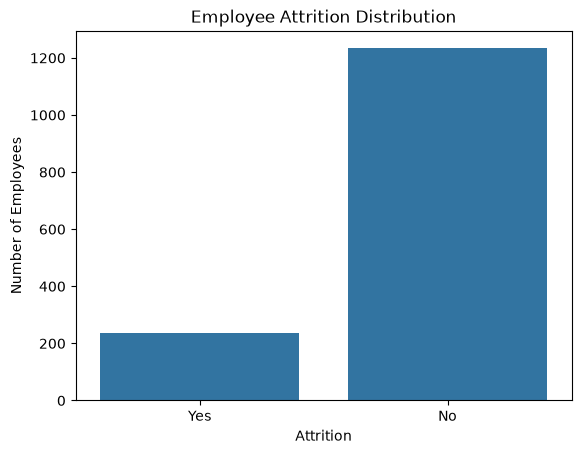

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

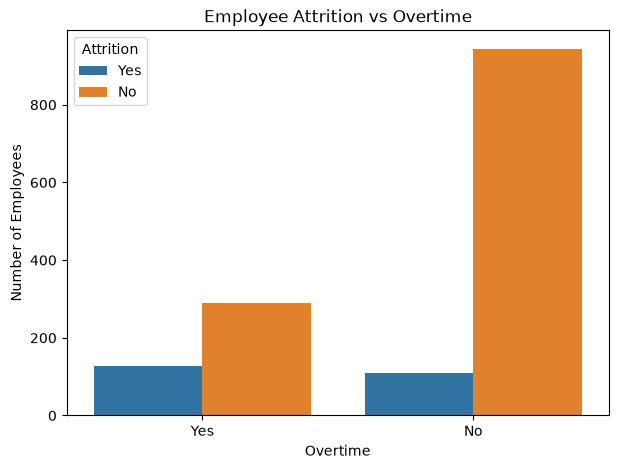

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("Employee Attrition vs Overtime")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.show()

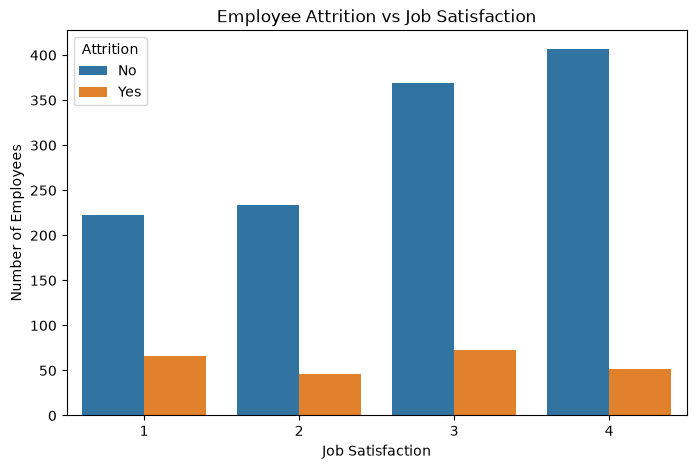

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Employee Attrition vs Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show()

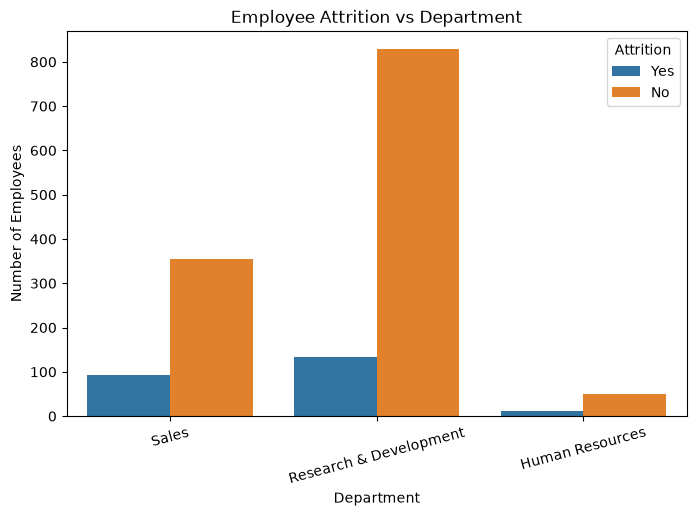

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Department", hue="Attrition")

plt.title("Employee Attrition vs Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)
plt.show()

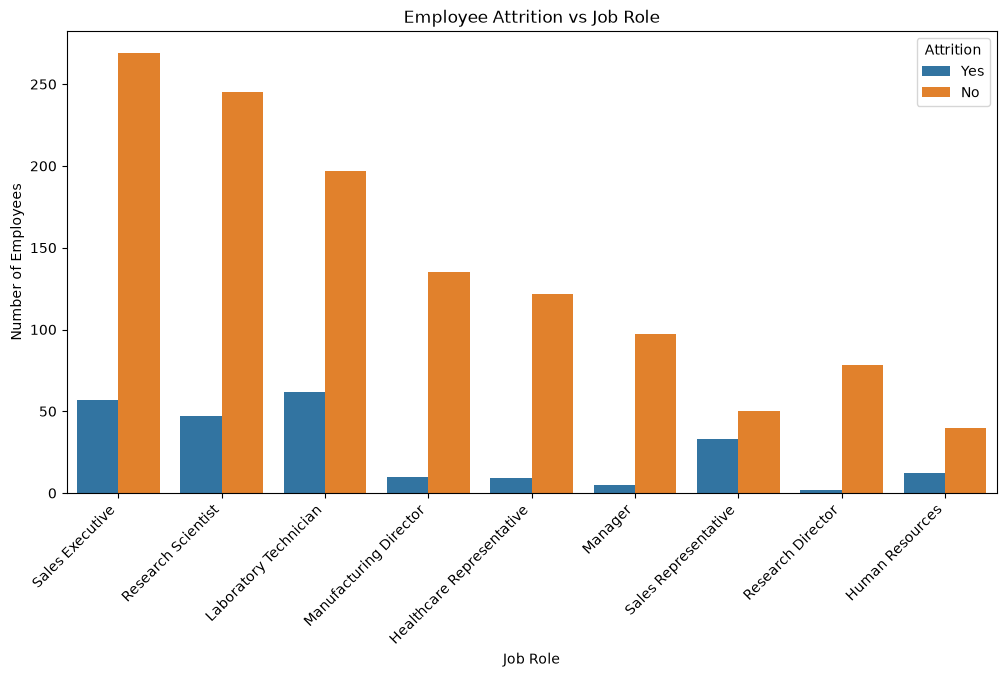

In [21]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="JobRole", hue="Attrition")

plt.title("Employee Attrition vs Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45, ha="right")
plt.show()

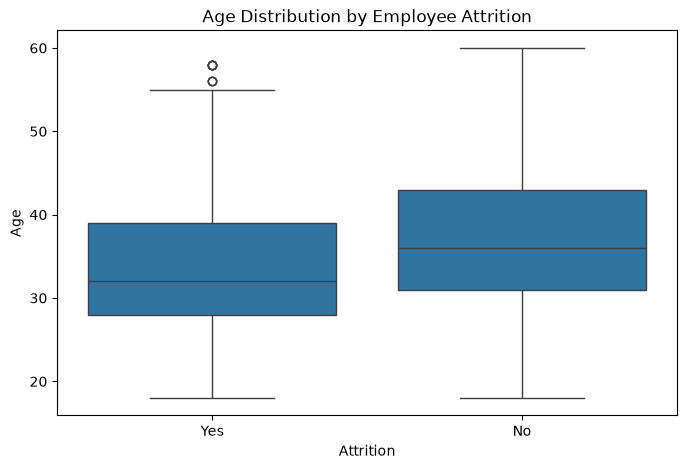

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age Distribution by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

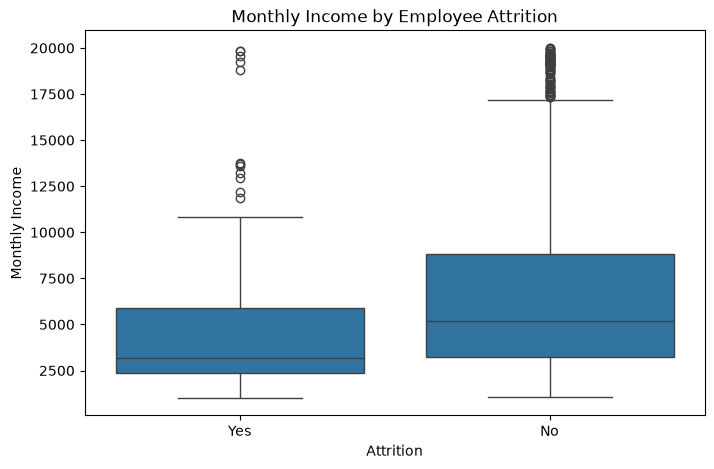

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

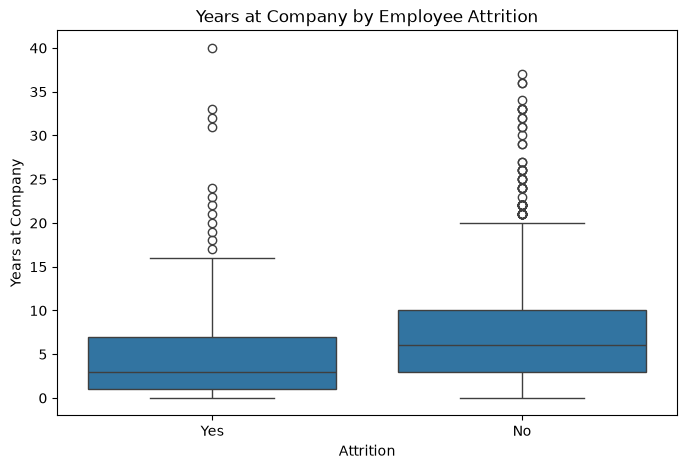

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")

plt.title("Years at Company by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.show()

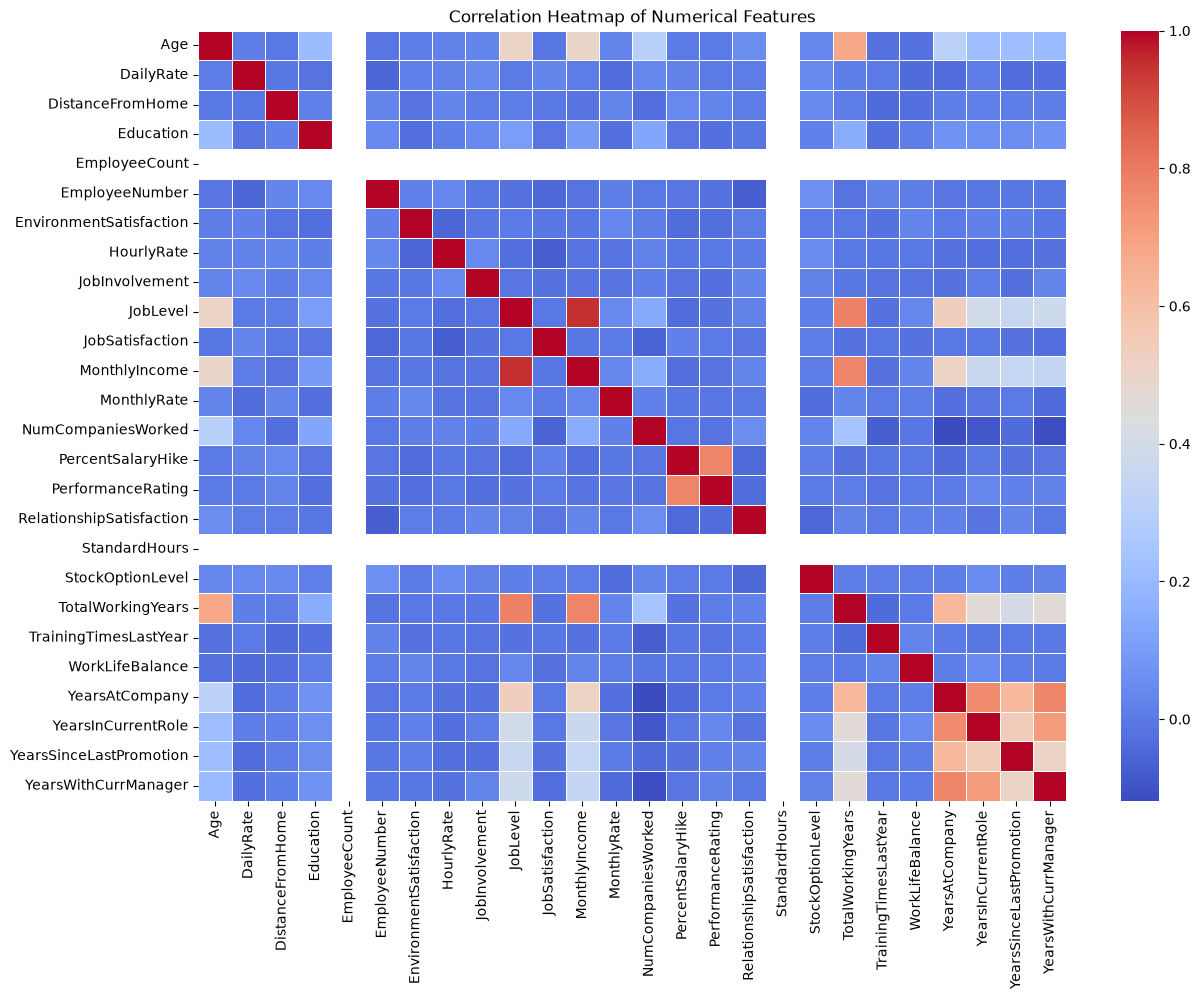

In [25]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [26]:
df_model = df.copy()

columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df_model = df_model.drop(columns=columns_to_drop)

print("Original shape:", df.shape)
print("Modeling shape:", df_model.shape)

Original shape: (1470, 35)
Modeling shape: (1470, 31)


In [27]:
X = df_model.drop("Attrition", axis=1)

y = df_model["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

X shape: (1470, 30)
y shape: (1470,)

Target values:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 30)
Testing data: (294, 30)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical features: 23
Categorical features: 7

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\Divya Jadon\AppData\Local\Temp\ipykernel_18984\2656512195.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=5
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [33]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, y_test, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results = []

results.append(
    evaluate_model("Logistic Regression", y_test, y_pred_logistic)
)

results.append(
    evaluate_model("Decision Tree", y_test, y_pred_tree)
)

results.append(
    evaluate_model("Random Forest", y_test, y_pred_rf)
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.717687,0.316327,0.659574,0.427586
1,Decision Tree,0.785714,0.378788,0.531915,0.442478
2,Random Forest,0.840136,0.500000,0.340426,0.405063


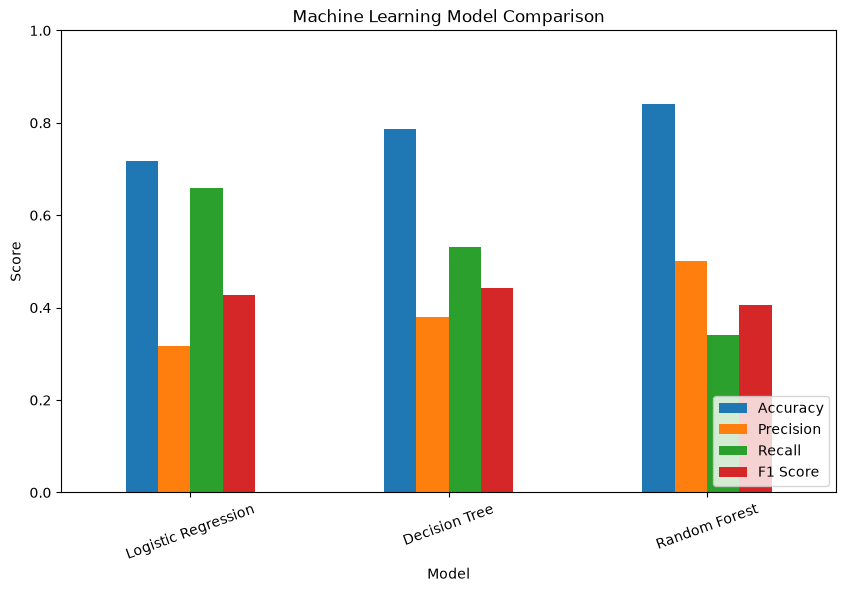

In [35]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()

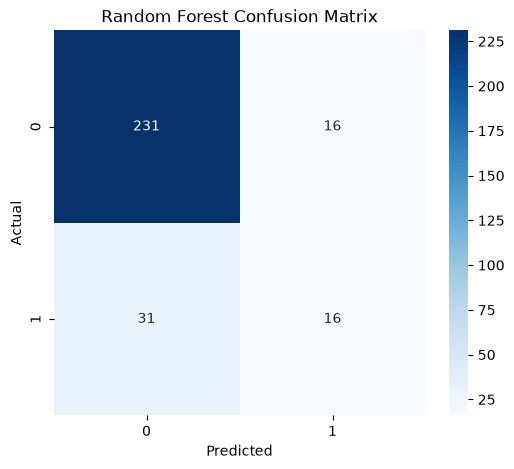

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
results = []

results.append(
    evaluate_model("Logistic Regression", y_test, y_pred_logistic)
)

results.append(
    evaluate_model("Decision Tree", y_test, y_pred_tree)
)

results.append(
    evaluate_model("Random Forest", y_test, y_pred_rf)
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.744898,0.333333,0.595745,0.427481
1,Decision Tree,0.785714,0.378788,0.531915,0.442478
2,Random Forest,0.840136,0.500000,0.340426,0.405063


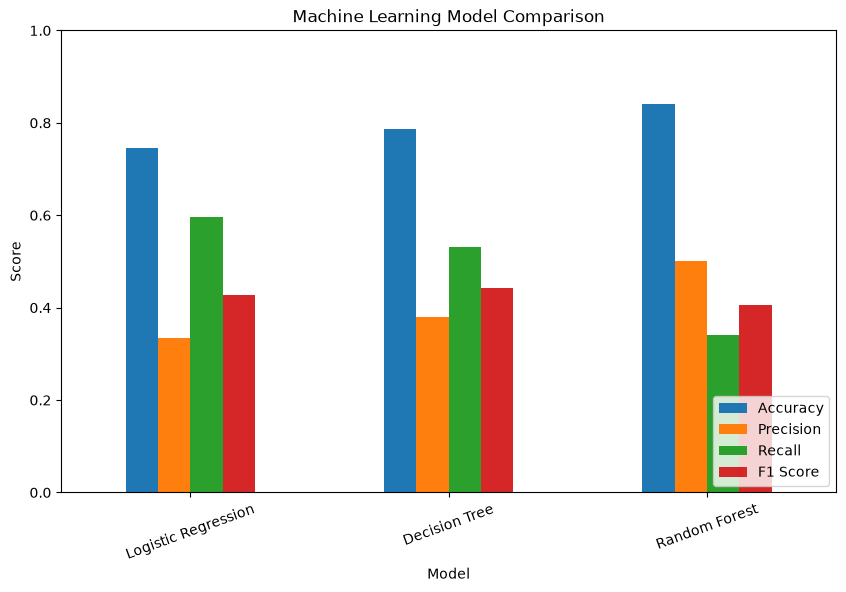

In [39]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()

In [40]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "../models/employee_attrition_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
